# Module 4: Train MobileNetV3 Target

This notebook is the first split-out stage of Module 4. It trains the clean MobileNetV3 target with centralized supervised learning and saves the V3 checkpoint consumed by the attack notebook.

Run this notebook from the `4_Adversarial_FL/` directory.


## Stage Goal

Establish a clean centralized MobileNetV3 target before introducing adversarial examples or federated clients. The handoff artifact is the configured target checkpoint, usually `artifacts/module4_v3_target.pt`, which the focused attack notebooks and Module 5 handoff use for transfer evaluation and FL initialization.


## 1. Notebook Setup

Load configuration, PyTorch, the shared dataset/evaluation helpers, and the MobileNetV3 model. This target notebook does not construct a federated server.


In [1]:
from contextlib import nullcontext
from copy import deepcopy
from pathlib import Path
import sys

MODULE_DIR = Path.cwd()
if (MODULE_DIR / "4_Adversarial_FL").exists():
    MODULE_DIR = MODULE_DIR / "4_Adversarial_FL"
SRC_DIR = MODULE_DIR / "src"
for path in (MODULE_DIR.parent, SRC_DIR):
    path_text = str(path)
    if path_text not in sys.path:
        sys.path.insert(0, path_text)

import json
import math
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from model import MobileNetV3Transfer
from util_functions import create_data, evaluate_fn, select_validation_subset, set_seed


## 2. Configuration and Artifact Setup

This cell loads `train_v3_config.yaml`, resolves the selected `target_training.profile`, validates centralized target-training settings, and writes the config snapshot used by downstream notebooks.

For this single-label 10-class target model, accuracy and top-1 accuracy mean the same thing: the highest-scoring predicted class matched the true label.

| Profile | Intended use | Key settings |
| --- | --- | --- |
| `quick` | Classroom smoke test and artifact handoff | 4 epochs, batch size 64, plain SGD, no scheduler |
| `tuned_imagenette` | Longer MobileNetV3-Small fine-tuning run | batch size 256, SGD momentum, warmup + cosine decay, AMP on CUDA |

The ImageNet recipes that use hundreds of epochs are reference points for full-scale training. For this Module 4 Imagenette handoff, prefer the quick profile for demos and the tuned profile only when the target checkpoint quality matters more than runtime.


In [2]:
CONFIG_PATH = Path("train_v3_config.yaml")
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Could not locate train_v3_config.yaml in the working directory")
with CONFIG_PATH.open() as f:
    CONFIG = yaml.safe_load(f)


def _merge_dicts(base: dict | None, override: dict | None) -> dict:
    merged = deepcopy(base or {})
    for key, value in (override or {}).items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key] = _merge_dicts(merged[key], value)
        else:
            merged[key] = deepcopy(value)
    return merged


global_config = deepcopy(CONFIG.get("global_config", {}))
data_config = deepcopy(CONFIG.get("data_config", {}))
model_config = deepcopy(CONFIG.get("model_config", {}))
alg_configs = deepcopy(CONFIG.get("algorithms", {}))
artifact_config = deepcopy(CONFIG.get("artifacts", {}))
target_training_selection = deepcopy(CONFIG.get("target_training", {}))
target_training_profiles = deepcopy(CONFIG.get("target_training_profiles", {}))

DEFAULT_FED_CONFIG = deepcopy(alg_configs.get("FedAvg", {}).get("fed_config", {}))
DEFAULT_TARGET_PROFILE = "tuned_imagenette"
TARGET_PROFILE = str(target_training_selection.get("profile", DEFAULT_TARGET_PROFILE))
if TARGET_PROFILE not in target_training_profiles:
    available = ", ".join(sorted(target_training_profiles)) or "none"
    raise ValueError(
        f"Unknown target_training.profile={TARGET_PROFILE!r}. Available profiles: {available}."
    )
TARGET_CFG = _merge_dicts(target_training_profiles.get(TARGET_PROFILE, {}), target_training_selection)
target_optimizer_config = TARGET_CFG.get("optimizer", {}) if isinstance(TARGET_CFG.get("optimizer", {}), dict) else {}
target_scheduler_config = TARGET_CFG.get("scheduler", {}) if isinstance(TARGET_CFG.get("scheduler", {}), dict) else {}
target_criterion_config = TARGET_CFG.get("criterion", {}) if isinstance(TARGET_CFG.get("criterion", {}), dict) else {}
TARGET_BATCH_SIZE = int(TARGET_CFG.get("batch_size", DEFAULT_FED_CONFIG.get("batch_size", 64)))
TARGET_EVAL_BATCH_SIZE = int(TARGET_CFG.get("eval_batch_size", 512))
TARGET_EPOCHS = int(TARGET_CFG.get("num_epochs", TARGET_CFG.get("epochs", DEFAULT_FED_CONFIG.get("num_epochs", 3))))
NUM_CLASSES = int(model_config.get("kwargs", {}).get("num_classes", 10))
set_seed(global_config.get("seed", 42))


def get_device(preferred: str | None = None) -> torch.device:
    choice = preferred if preferred is not None else global_config.get("device")
    if isinstance(choice, str):
        if choice.startswith("cuda") and not torch.cuda.is_available():
            choice = "cpu"
        return torch.device(choice)
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


DEVICE = get_device()
global_config["device"] = str(DEVICE)

ARTIFACT_DIR = Path(artifact_config.get("dir", "artifacts"))
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def artifact_path(key: str, default_filename: str) -> Path:
    return ARTIFACT_DIR / artifact_config.get(key, default_filename)


def validate_target_config() -> None:
    issues = []
    optimizer_name = str(target_optimizer_config.get("name", "sgd")).lower()
    scheduler_name = str(target_scheduler_config.get("name", "none")).lower()
    label_smoothing = float(target_criterion_config.get("label_smoothing", TARGET_CFG.get("label_smoothing", 0.0)))
    if not data_config.get("dataset_path"):
        issues.append("data_config.dataset_path is required for centralized target training.")
    if not data_config.get("dataset_name"):
        issues.append("data_config.dataset_name is required for centralized target training.")
    if model_config.get("name") != "MobileNetV3Transfer":
        issues.append("model_config.name should be MobileNetV3Transfer for train_v3.ipynb.")
    if TARGET_EPOCHS <= 0:
        issues.append("target_training.num_epochs must be positive.")
    if TARGET_BATCH_SIZE <= 0:
        issues.append("target_training.batch_size must be positive.")
    if optimizer_name not in {"sgd", "local_sgd", "adam", "adamw"}:
        issues.append("target_training.optimizer.name must be one of: sgd, local_sgd, adam, adamw.")
    if scheduler_name not in {"none", "cosine", "warmup_cosine", "plateau", "reduce_on_plateau"}:
        issues.append("target_training.scheduler.name must be one of: none, cosine, warmup_cosine, plateau, reduce_on_plateau.")
    if scheduler_name == "warmup_cosine" and int(target_scheduler_config.get("warmup_epochs", 0)) < 0:
        issues.append("target_training.scheduler.warmup_epochs cannot be negative.")
    if not 0.0 <= label_smoothing < 1.0:
        issues.append("target_training.criterion.label_smoothing must be in [0, 1).")
    if issues:
        raise ValueError("Target-training config validation failed:\n" + "\n".join(issues))

    lr = float(target_optimizer_config.get("lr", target_optimizer_config.get("learning_rate", DEFAULT_FED_CONFIG.get("local_stepsize", 1e-3))))
    if optimizer_name in {"adam", "adamw"} and lr >= 1e-3:
        print(
            "Config note: Adam/AdamW usually need a much lower fine-tuning LR than SGD. "
            "If validation accuracy drops during warmup, try lr in the 1e-4 to 3e-4 range "
            "or switch back to SGD with momentum."
        )
    print(
        "Centralized target config ready: "
        f"profile={TARGET_PROFILE}, device={DEVICE}, dataset={data_config.get('dataset_name')}, "
        f"epochs={TARGET_EPOCHS}, batch_size={TARGET_BATCH_SIZE}, optimizer={optimizer_name}, "
        f"scheduler={scheduler_name}, lr={lr:.3g}"
    )


validate_target_config()

config_snapshot = deepcopy(CONFIG)
config_snapshot.setdefault("global_config", {})["resolved_device"] = str(DEVICE)
config_snapshot.setdefault("target_training", {})["selected_profile"] = TARGET_PROFILE
config_snapshot.setdefault("target_training", {})["resolved_mode"] = "centralized"
config_snapshot["target_training_effective"] = deepcopy(TARGET_CFG)
config_path = artifact_path("config_snapshot", "module4_target_config_used.json")
with config_path.open("w") as f:
    json.dump(config_snapshot, f, indent=2)

print("Loaded config from", CONFIG_PATH.resolve())
print(f"Saved config snapshot to {config_path.resolve()}")


Centralized target config ready: profile=tuned_imagenette, device=cuda, dataset=Imagenette, epochs=500, batch_size=64, optimizer=sgd, scheduler=warmup_cosine, lr=0.002
Loaded config from /home/ahoop004/T3-Ciders-FL/4_Adversarial_FL/train_v3_config.yaml
Saved config snapshot to /home/ahoop004/T3-Ciders-FL/4_Adversarial_FL/artifacts/module4_target_config_used.json


## 3. Centralized Target Data

Load the configured dataset once and build standard train/test loaders. These loaders are not split by client.


In [3]:
def _target_eval_subset_name() -> str:
    return str(TARGET_CFG.get("eval_subset", data_config.get("eval_subset", "selection")))


def build_target_loaders() -> tuple[DataLoader, DataLoader, str, int]:
    train_dataset, full_val_dataset = create_data(
        data_config["dataset_path"],
        data_config["dataset_name"],
    )
    eval_subset = _target_eval_subset_name()
    validation_dataset = select_validation_subset(
        full_val_dataset,
        data_config.get("validation_split"),
        eval_subset,
    )
    num_workers = int(TARGET_CFG.get("num_workers", 0))
    pin_memory = bool(TARGET_CFG.get("pin_memory", DEVICE.type == "cuda"))
    train_loader = DataLoader(
        train_dataset,
        batch_size=TARGET_BATCH_SIZE,
        shuffle=True,
        drop_last=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    validation_loader = DataLoader(
        validation_dataset,
        batch_size=TARGET_EVAL_BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    return train_loader, validation_loader, eval_subset, len(full_val_dataset)


target_train_loader, target_test_loader, TARGET_EVAL_SUBSET, TARGET_FULL_VAL_EXAMPLES = build_target_loaders()
print(
    f"Centralized target data ready: train_examples={len(target_train_loader.dataset)}, "
    f"validation_subset={TARGET_EVAL_SUBSET}, "
    f"validation_examples={len(target_test_loader.dataset)} "
    f"of full_val_examples={TARGET_FULL_VAL_EXAMPLES}"
)


Centralized target data ready: train_examples=9469, validation_subset=selection, validation_examples=1963 of full_val_examples=3925


## 4. Target Training Helpers

Define the MobileNetV3 model, loss, optimizer, scheduler, AMP helpers, and training loop used for centralized target training.


In [4]:
def build_target_model(pretrained: bool | None = None) -> torch.nn.Module:
    kwargs = deepcopy(model_config.get("kwargs", {}))
    kwargs["num_classes"] = NUM_CLASSES
    if pretrained is not None:
        kwargs["pretrained"] = pretrained
    model = MobileNetV3Transfer(**kwargs).to(DEVICE)
    if TARGET_CFG.get("freeze_backbone", False) and hasattr(model, "v3model"):
        for param in model.v3model.features.parameters():
            param.requires_grad = False
    return model


def build_target_criterion() -> torch.nn.Module:
    label_smoothing = float(target_criterion_config.get("label_smoothing", TARGET_CFG.get("label_smoothing", 0.0)))
    return torch.nn.CrossEntropyLoss(label_smoothing=label_smoothing).to(DEVICE)


def build_target_optimizer(model: torch.nn.Module) -> torch.optim.Optimizer:
    name = str(target_optimizer_config.get("name", "sgd")).lower()
    if name == "local_sgd":
        name = "sgd"
    lr = float(target_optimizer_config.get("lr", target_optimizer_config.get("learning_rate", DEFAULT_FED_CONFIG.get("local_stepsize", 1e-3))))
    weight_decay = float(target_optimizer_config.get("weight_decay", 0.0))
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if not trainable_params:
        raise RuntimeError("No trainable parameters available for target optimisation.")

    if name == "adamw":
        return torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    if name == "adam":
        return torch.optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)
    if name == "sgd":
        momentum = float(target_optimizer_config.get("momentum", 0.0))
        return torch.optim.SGD(trainable_params, lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unsupported target optimizer: {name}")


class WarmupCosineScheduler:
    def __init__(
        self,
        optimizer: torch.optim.Optimizer,
        total_epochs: int,
        warmup_epochs: int,
        min_lr: float,
        warmup_start_factor: float = 0.1,
    ):
        self.optimizer = optimizer
        self.total_epochs = max(int(total_epochs), 1)
        self.warmup_epochs = max(int(warmup_epochs), 0)
        self.min_lr = float(min_lr)
        self.warmup_start_factor = float(warmup_start_factor)
        self.base_lrs = [float(group["lr"]) for group in optimizer.param_groups]
        self.last_epoch = 0
        self._set_lrs(self._compute_lrs(self.last_epoch))

    def _compute_lrs(self, epoch_index: int) -> list[float]:
        if self.warmup_epochs > 0 and epoch_index < self.warmup_epochs:
            if self.warmup_epochs == 1:
                factor = 1.0
            else:
                progress = epoch_index / max(self.warmup_epochs - 1, 1)
                factor = self.warmup_start_factor + (1.0 - self.warmup_start_factor) * progress
            return [base_lr * factor for base_lr in self.base_lrs]

        cosine_epochs = max(self.total_epochs - self.warmup_epochs, 1)
        progress = min(max(epoch_index - self.warmup_epochs, 0) / cosine_epochs, 1.0)
        cosine_factor = 0.5 * (1.0 + math.cos(math.pi * progress))
        return [self.min_lr + (base_lr - self.min_lr) * cosine_factor for base_lr in self.base_lrs]

    def _set_lrs(self, lrs: list[float]) -> None:
        for group, lr in zip(self.optimizer.param_groups, lrs):
            group["lr"] = float(lr)

    def step(self) -> None:
        self.last_epoch += 1
        self._set_lrs(self._compute_lrs(self.last_epoch))


def build_target_scheduler(optimizer: torch.optim.Optimizer, epochs: int):
    name = str(target_scheduler_config.get("name", "none")).lower()
    if name == "none":
        return None
    if name == "cosine":
        min_lr = float(target_scheduler_config.get("min_lr", target_scheduler_config.get("eta_min", 0.0)))
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(int(epochs), 1),
            eta_min=min_lr,
        )
    if name == "warmup_cosine":
        return WarmupCosineScheduler(
            optimizer,
            total_epochs=epochs,
            warmup_epochs=int(target_scheduler_config.get("warmup_epochs", 5)),
            min_lr=float(target_scheduler_config.get("min_lr", target_scheduler_config.get("eta_min", 0.0))),
            warmup_start_factor=float(target_scheduler_config.get("warmup_start_factor", 0.1)),
        )
    if name in {"plateau", "reduce_on_plateau"}:
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=float(target_scheduler_config.get("factor", 0.5)),
            patience=int(target_scheduler_config.get("patience", 1)),
        )
    raise ValueError(f"Unsupported target scheduler: {name}")


def _step_target_scheduler(scheduler, val_loss: float) -> None:
    if scheduler is None:
        return
    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(val_loss)
    else:
        scheduler.step()


def build_target_amp(requested: bool):
    enabled = bool(requested) and DEVICE.type == "cuda"
    if requested and not enabled:
        print("AMP requested but disabled because the resolved device is not CUDA.")
    scaler = None
    if enabled:
        if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
            try:
                scaler = torch.amp.GradScaler("cuda", enabled=True)
            except TypeError:
                scaler = torch.amp.GradScaler(enabled=True)
        else:
            scaler = torch.cuda.amp.GradScaler(enabled=True)
    return enabled, scaler


def target_amp_autocast(enabled: bool):
    if not enabled:
        return nullcontext()
    if hasattr(torch, "amp") and hasattr(torch.amp, "autocast"):
        try:
            return torch.amp.autocast(device_type="cuda", enabled=True)
        except TypeError:
            pass
    return torch.cuda.amp.autocast(enabled=True)


def train_target_model(num_epochs: int | None = None):
    set_seed(global_config.get("seed", 42))
    model = build_target_model().to(DEVICE)
    criterion = build_target_criterion()
    optimizer = build_target_optimizer(model)
    epochs = int(num_epochs or TARGET_EPOCHS)
    scheduler = build_target_scheduler(optimizer, epochs)
    patience = int(TARGET_CFG.get("early_stop_patience", 0))
    use_amp, scaler = build_target_amp(bool(TARGET_CFG.get("use_amp", False)))
    history = {
        "loss": [],
        "accuracy": [],
        "top1_accuracy": [],  # compatibility alias; same as accuracy for single-label classification
        "val_loss": [],
        "val_accuracy": [],
        "val_top1_accuracy": [],  # compatibility alias; same as val_accuracy
        "lr": [],
    }
    best_state = None
    best_val_loss = float("inf")
    best_val_accuracy = 0.0
    best_checkpoint_epoch = 0
    best_checkpoint_val_accuracy = 0.0
    epochs_since_improved = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0
        correct = 0
        epoch_lr = float(optimizer.param_groups[0]["lr"])
        for inputs, labels in target_train_loader:
            inputs = inputs.to(DEVICE).float()
            labels = labels.to(DEVICE).long()
            optimizer.zero_grad(set_to_none=True)
            with target_amp_autocast(use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()

        epoch_loss = running_loss / max(total, 1)
        epoch_acc = 100.0 * correct / max(total, 1)
        val_loss, val_acc = evaluate_fn(target_test_loader, model, criterion, DEVICE)
        _step_target_scheduler(scheduler, val_loss)
        history["loss"].append(float(epoch_loss))
        history["accuracy"].append(float(epoch_acc))
        history["top1_accuracy"].append(float(epoch_acc))
        history["val_loss"].append(float(val_loss))
        history["val_accuracy"].append(float(val_acc))
        history["val_top1_accuracy"].append(float(val_acc))
        history["lr"].append(epoch_lr)
        best_val_accuracy = max(best_val_accuracy, float(val_acc))

        improved = val_loss + 1e-5 < best_val_loss
        if improved:
            best_val_loss = float(val_loss)
            best_checkpoint_epoch = epoch + 1
            best_checkpoint_val_accuracy = float(val_acc)
            best_state = deepcopy(model.state_dict())
            epochs_since_improved = 0
            status = "saved best checkpoint"
        else:
            epochs_since_improved += 1
            status = (
                f"no val-loss improvement ({epochs_since_improved}/{patience})"
                if patience
                else "no val-loss improvement"
            )

        print(
            f"Epoch {epoch + 1}/{epochs}: "
            f"train_loss={epoch_loss:.4f}, train_acc={epoch_acc:.2f}%, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}%, "
            f"lr={epoch_lr:.2e} - {status}"
        )
        if not improved and patience and epochs_since_improved >= patience:
            print(f"Stopping early at epoch {epoch + 1} after {patience} epochs without validation-loss improvement.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    test_loss, test_acc = evaluate_fn(target_test_loader, model, criterion, DEVICE)
    last_train_acc = float(history["accuracy"][-1]) if history["accuracy"] else 0.0
    final_val_acc = float(test_acc)
    train_val_gap = float(last_train_acc - final_val_acc)
    summary = {
        "training_mode": "centralized",
        "target_training_profile": TARGET_PROFILE,
        "profile_description": TARGET_CFG.get("description", ""),
        "model": "MobileNetV3Transfer",
        "dataset": data_config.get("dataset_name"),
        "eval_subset": TARGET_EVAL_SUBSET,
        "validation_subset": TARGET_EVAL_SUBSET,
        "validation_examples": len(target_test_loader.dataset),
        "full_validation_examples": TARGET_FULL_VAL_EXAMPLES,
        "history": history,
        "final_loss": float(test_loss),
        "final_accuracy": final_val_acc,
        "final_top1_accuracy": final_val_acc,
        "best_val_loss": float(best_val_loss),
        "best_val_accuracy": float(best_val_accuracy),
        "best_val_top1_accuracy": float(best_val_accuracy),
        "best_checkpoint_epoch": int(best_checkpoint_epoch),
        "best_checkpoint_val_accuracy": float(best_checkpoint_val_accuracy),
        "checkpoint_selection_metric": "lowest_val_loss",
        "last_train_accuracy": last_train_acc,
        "final_train_accuracy": last_train_acc,
        "final_train_top1_accuracy": last_train_acc,
        "final_train_val_accuracy_gap": train_val_gap,
        "final_train_val_top1_gap": train_val_gap,
        "epochs_completed": len(history["loss"]),
        "batch_size": TARGET_BATCH_SIZE,
        "optimizer": deepcopy(target_optimizer_config),
        "scheduler": deepcopy(target_scheduler_config),
        "criterion": deepcopy(target_criterion_config),
        "model_kwargs": deepcopy(model_config.get("kwargs", {})),
        "use_amp": use_amp,
    }
    return model, summary


## 5. Train and Save the V3 Target

Run centralized target training and save both metrics and the checkpoint that seeds the attack notebook.


In [5]:
target_model, target_summary = train_target_model()

print("Metric note: accuracy means top-1 accuracy here: the model's highest-scoring class matched the label.")
print(
    "Centralized V3 target result:\n"
    f"  profile: {target_summary['target_training_profile']}\n"
    f"  checkpoint selected: epoch {target_summary.get('best_checkpoint_epoch', 'n/a')} "
    f"by {target_summary.get('checkpoint_selection_metric', 'validation metric')}\n"
    f"  validation loss: {target_summary['final_loss']:.4f}\n"
    f"  validation accuracy: {target_summary['final_accuracy']:.2f}%\n"
    f"  best validation accuracy seen: {target_summary.get('best_val_accuracy', target_summary['final_accuracy']):.2f}%\n"
    f"  epochs run: {target_summary['epochs_completed']}\n"
    f"  last train accuracy: {target_summary['last_train_accuracy']:.2f}%\n"
    f"  last-train minus checkpoint-val gap: {target_summary['final_train_val_accuracy_gap']:.2f} points"
)

target_summary_preview = {
    "profile": target_summary["target_training_profile"],
    "checkpoint_selection_metric": target_summary["checkpoint_selection_metric"],
    "best_checkpoint_epoch": target_summary["best_checkpoint_epoch"],
    "validation_loss": target_summary["final_loss"],
    "validation_accuracy": target_summary["final_accuracy"],
    "best_validation_accuracy_seen": target_summary["best_val_accuracy"],
    "epochs_completed": target_summary["epochs_completed"],
    "last_train_accuracy": target_summary["last_train_accuracy"],
    "train_val_accuracy_gap_points": target_summary["final_train_val_accuracy_gap"],
    "optimizer": target_summary["optimizer"],
    "scheduler": target_summary["scheduler"],
}

target_summary_preview


Epoch 1/500: train_loss=1.6594, train_acc=60.91%, val_loss=0.9825, val_acc=87.16%, lr=2.00e-04 - saved best checkpoint
Epoch 2/500: train_loss=0.5383, train_acc=92.21%, val_loss=0.2940, val_acc=94.55%, lr=6.50e-04 - saved best checkpoint
Epoch 3/500: train_loss=0.2338, train_acc=95.14%, val_loss=0.1759, val_acc=95.62%, lr=1.10e-03 - saved best checkpoint
Epoch 4/500: train_loss=0.1536, train_acc=96.29%, val_loss=0.1341, val_acc=96.38%, lr=1.55e-03 - saved best checkpoint
Epoch 5/500: train_loss=0.1128, train_acc=97.04%, val_loss=0.1109, val_acc=96.74%, lr=2.00e-03 - saved best checkpoint
Epoch 6/500: train_loss=0.0881, train_acc=97.92%, val_loss=0.0919, val_acc=97.35%, lr=2.00e-03 - saved best checkpoint
Epoch 7/500: train_loss=0.0694, train_acc=98.35%, val_loss=0.0853, val_acc=97.35%, lr=2.00e-03 - saved best checkpoint
Epoch 8/500: train_loss=0.0570, train_acc=98.61%, val_loss=0.0789, val_acc=97.55%, lr=2.00e-03 - saved best checkpoint
Epoch 9/500: train_loss=0.0473, train_acc=98.88%

{'profile': 'tuned_imagenette',
 'checkpoint_selection_metric': 'lowest_val_loss',
 'best_checkpoint_epoch': 25,
 'validation_loss': 0.06286588544026017,
 'validation_accuracy': 97.65664798777381,
 'best_validation_accuracy_seen': 97.91136016301579,
 'epochs_completed': 33,
 'last_train_accuracy': 99.95775689090718,
 'train_val_accuracy_gap_points': 2.3011089031333682,
 'optimizer': {'name': 'sgd',
  'lr': 0.002,
  'momentum': 0.9,
  'weight_decay': 4e-05},
 'scheduler': {'name': 'warmup_cosine', 'warmup_epochs': 5, 'min_lr': 1e-05}}

### Save and Validate the Target

Save `module4_target_training.json` and the MobileNetV3 checkpoint. The checkpoint name is configurable through `artifacts.target_checkpoint`.


In [6]:
target_metrics_path = artifact_path("target_metrics", "module4_target_training.json")
with target_metrics_path.open("w") as f:
    json.dump(target_summary, f, indent=2)

target_checkpoint_path = artifact_path("target_checkpoint", "module4_v3_target.pt")
torch.save(target_model.state_dict(), target_checkpoint_path)

acc = float(target_summary.get("final_accuracy", target_summary.get("final_top1_accuracy", 0.0)))
loss = float(target_summary.get("final_loss", float("nan")))
history_len = int(target_summary.get("epochs_completed", 0))
if not np.isfinite(loss):
    raise ValueError("Target loss is not finite; revisit training settings.")
if history_len <= 0:
    raise ValueError("Target training history is empty.")
if acc < 5.0:
    raise ValueError(f"Target validation accuracy {acc:.2f}% is suspiciously low; revisit training settings.")

print(f"Target validation accuracy: {acc:.2f}%")
print(f"Saved details to {target_metrics_path.resolve()}")
print(f"Saved checkpoint to {target_checkpoint_path.resolve()}")


Target validation accuracy: 97.66%
Saved details to /home/ahoop004/T3-Ciders-FL/4_Adversarial_FL/artifacts/module4_target_training.json
Saved checkpoint to /home/ahoop004/T3-Ciders-FL/4_Adversarial_FL/artifacts/module4_v3_target.pt


### Target Training Curves

Plot the centralized target training and validation curves. These curves show loss and accuracy before the checkpoint is used by the focused attack notebooks.


In [7]:
def plot_target_history(summary: dict) -> None:
    history = summary.get("history", {})
    if not history.get("loss"):
        print("No target history to plot.")
        return
    epochs = range(1, len(history["loss"]) + 1)
    train_acc = history.get("accuracy", history.get("top1_accuracy", []))
    val_acc = history.get("val_accuracy", history.get("val_top1_accuracy", []))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs, history["loss"], marker="o", label="train")
    axes[0].plot(epochs, history.get("val_loss", []), marker="s", label="val")
    axes[0].set_title("V3 target loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, train_acc, marker="o", label="train")
    axes[1].plot(epochs, val_acc, marker="s", label="val")
    axes[1].set_title("V3 target accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    plot_path = artifact_path("target_history_plot", "target_training_history.png")
    fig.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Saved target training curves to {plot_path.resolve()}")


plot_target_history(target_summary)


Saved target training curves to /home/ahoop004/T3-Ciders-FL/4_Adversarial_FL/artifacts/target_training_history.png


### View Saved Plot Artifacts

Display the plot files written to `artifacts/`. This is useful after reopening the notebook or clearing inline cell outputs.


Target training history: /home/ahoop004/T3-Ciders-FL/4_Adversarial_FL/artifacts/target_training_history.png


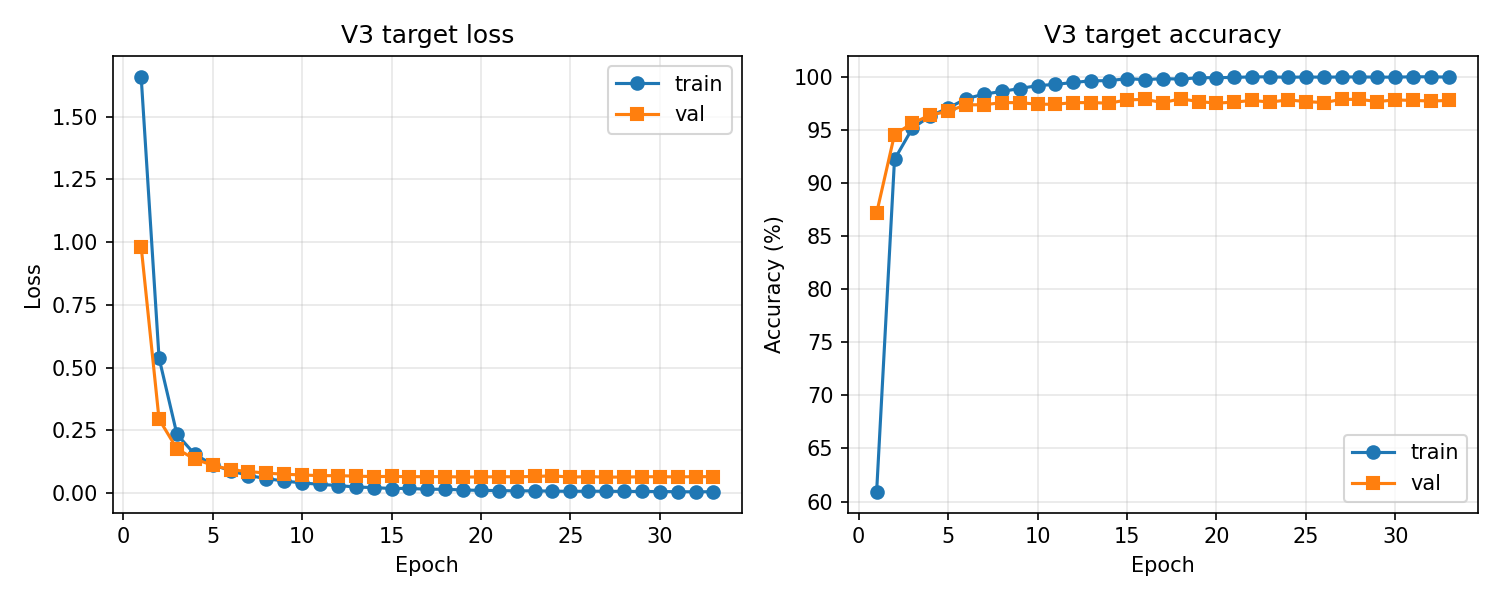

In [8]:
from IPython.display import Image, display

plot_artifacts = {
    "Target training history": artifact_path("target_history_plot", "target_training_history.png"),
}

for label, path in plot_artifacts.items():
    if path.exists():
        print(f"{label}: {path.resolve()}")
        display(Image(filename=str(path)))
    else:
        print(f"{label}: not found at {path.resolve()}")


## Handoff Artifacts

After this notebook runs, the focused attack notebooks expect the target checkpoint in `artifacts/`.

| Artifact | Used by |
| --- | --- |
| `module4_target_config_used.json` | Target training recipe and resolved profile |
| `module4_target_training.json` | Target quality check before attacks |
| `module4_v3_target.pt` | Transfer evaluation and clean-vs-attacked FedAvg initialization |
| `target_training_history.png` | Instructor/student target training inspection |
